# 2. Decay compartment

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{indir}analysis/compartment/L1/comp.{mode}.hdf'`  ·  _compartment_
- `f'{indir}clustering/merged/5kCG100k3C_summary.h5ad'`  ·  _joint summary obj_
- `f'decay_compartment/{ct}_histdiff_{mode}.npy'`  ·  _compartment_
- `f'decay_compartment/{ct}_histsum_{mode}.npy'`  ·  _compartment_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import os
import time
import cooler
from glob import glob
from concurrent.futures import ProcessPoolExecutor, as_completed

import qnorm
import anndata
from scipy.stats import zscore

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [ ]:
indir = f'{ENTEX_ROOT}/'


In [ ]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [ ]:
res = 100000
chrom_size_path = '/large_experiments/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [ ]:
mode = 'impute'
compall = pd.read_hdf(f'{indir}analysis/compartment/L1/comp.{mode}.hdf', key='data')
compall.index = compall['chrom'].astype(str) + '-' + (compall['start'] // res).astype(str)
binfilter = compall['raw_binfilter'].copy()

In [ ]:
tmp = compall.loc[binfilter, compall.columns[4:]]
tmp = qnorm.quantile_normalize(tmp)
compall.loc[binfilter, compall.columns[4:]] = tmp

In [ ]:
compall.to_hdf(f'compartment/L1/comp.{mode}.qnorm.hdf', key='data')


In [ ]:
distbin = np.power(10, np.arange(5, 8.01, 3/100))
# difflogbin = np.power(10, np.arange(-2.5, 0.61, 3.1/50))
diffbin = np.arange(0, 30.01, 30/50)
sumbin = np.arange(-15, 15.01, 30/50)


In [ ]:
chrom1 = 1
chrom2 = 5
pos1 = 2
pos2 = 6

def contact_hist(contact_path, ct):
    data = pd.read_csv(contact_path, sep='\t', header=None, index_col=None)
    data = data.loc[(data[chrom1]==data[chrom2]) & data[chrom1].isin(chrom_sizes.index)]
    data['dist'] = np.abs(data[pos1] - data[pos2])
    l = data[chrom1] + '-' + (data[pos1] // res).astype(str)
    r = data[chrom2] + '-' + (data[pos2] // res).astype(str)
    datafilter = (compall.loc[l, 'raw_binfilter'].values) & (compall.loc[r, 'raw_binfilter'].values) & (data['dist']>res)
    l, r, data = l[datafilter], r[datafilter], data.loc[datafilter]
    data['compdiff'] = np.abs(compall.loc[l, ct].values - compall.loc[r, ct].values)
    data['compsum'] = (compall.loc[l, ct].values + compall.loc[r, ct].values) / 2
    histdiff = np.histogram2d(data['dist'], data['compdiff'], bins=[distbin, diffbin])[0]
    histsum = np.histogram2d(data['dist'], data['compsum'], bins=[distbin, sumbin])[0]
    return histdiff, histsum
   

In [ ]:
meta = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad').obs


In [ ]:
# contact_hist(contact_path=f'{indir}contact/{cell}.3C.contact.rmbkl.tsv.gz', ct=ct)

In [ ]:
cpu = 32
for ct in L1_meta.index:
    histdiff = np.zeros((len(distbin)-1, len(diffbin)-1))
    histsum = np.zeros((len(distbin)-1, len(sumbin)-1))
    with ProcessPoolExecutor(cpu) as executor:
        futures = {}
        for cell in meta.index[meta['L1']==ct]:
            future = executor.submit(
                contact_hist,
                contact_path=f'{indir}contact/{cell}.3C.contact.rmbkl.tsv.gz',
                ct=ct,
            )
            futures[future] = cell
        for future in as_completed(futures):
            cell = futures[future]
            xx, yy = future.result()
            histdiff += xx
            histsum += yy
            # print(f'{cell} finished')

    np.save(f'decay_compartment/{ct}_histdiff_{mode}.npy', histdiff)
    np.save(f'decay_compartment/{ct}_histsum_{mode}.npy', histsum)
    print(f'{ct} finished')


In [ ]:
distticks = (np.log10([2e5,2e6,1e7,1e8]) - 5) * 100 / 3 - 0.5
distticklabels = ['200k', '2M', '10M', '100M']
diffticks = np.arange(0, 51, 50/3) - 0.5
diffticklabels = np.arange(0, 31, 10)
# difflogticks = np.arange(0,51,10)
# difflogticklabels = list(map(lambda x:'{:.2e}'.format(x), diffbin[diffticks]))
sumticks = np.arange(0, 51, 50/3) - 0.5
sumticklabels = np.arange(-15, 16, 10)


In [ ]:
leg = meta.groupby('L1')['Short/Long'].median().sort_values().index[::-1]


In [ ]:
mode = 'impute'
histdiff, histsum = [], []
for ct in leg:
    tmpdiff = np.load(f'decay_compartment/{ct}_histdiff_{mode}.npy')
    tmpsum = np.load(f'decay_compartment/{ct}_histsum_{mode}.npy')
    histdiff.append(tmpdiff)
    histsum.append(tmpsum)
    

In [ ]:
refdiff = np.sum(histdiff, axis=0)
refsum = np.sum(histsum, axis=0)
refdiff = refdiff / refdiff.sum(axis=1)[:, None]
refsum = refsum / refsum.sum(axis=1)[:, None]


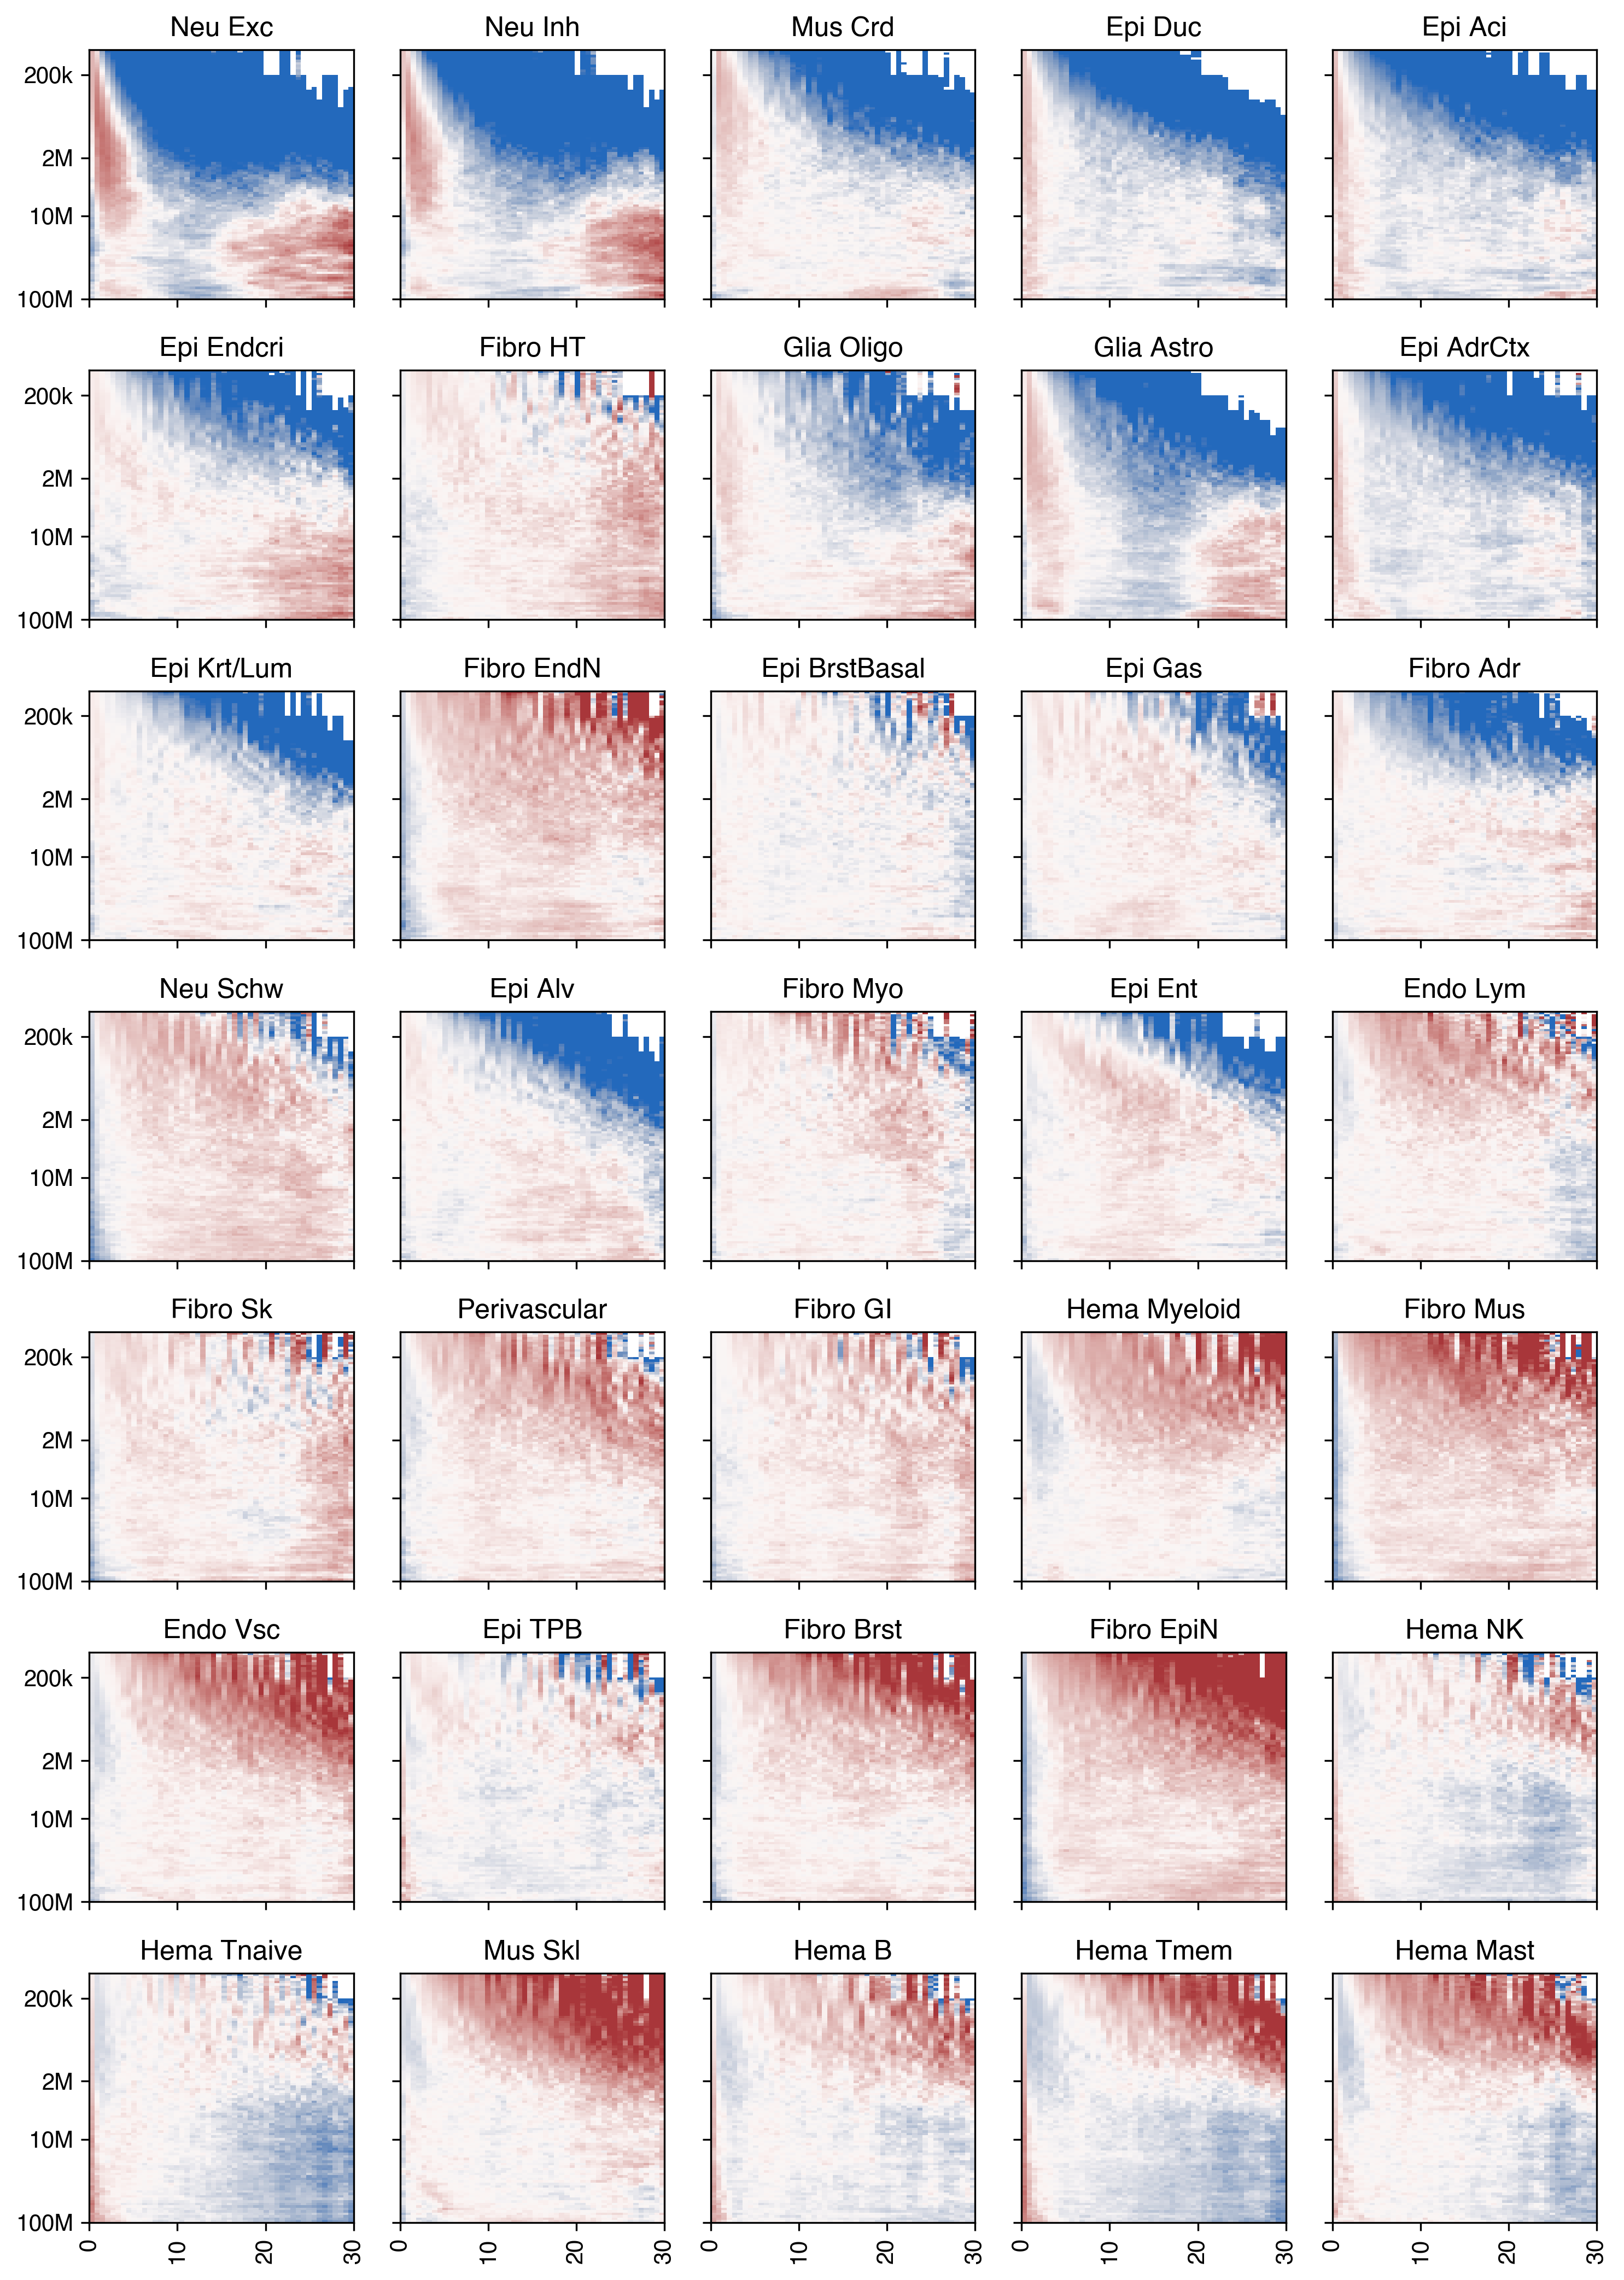

In [ ]:
fig, axes = plt.subplots(7, 5, figsize=(10, 14), sharex='all', sharey='all', dpi=300)
for i,ct in enumerate(leg):
    ax = axes.flatten()[i]
    tmp = histdiff[i].copy()
    tmp = tmp / tmp.sum(axis=1)[:, None]
    tmp = np.log2(tmp / refdiff)
    xticks = diffticks.copy()
    xticklabels = diffticklabels.copy()
    ax.imshow(tmp, cmap='vlag', aspect='auto', interpolation='none', vmin=-1, vmax=1)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=90)
    ax.set_title(L1_annot[ct])
    ax.set_yticks(distticks)
    ax.set_yticklabels(distticklabels)

fig.tight_layout()
fig.savefig('decay_compartment/compdiff_dist_heatmap.pdf', transparent=True)


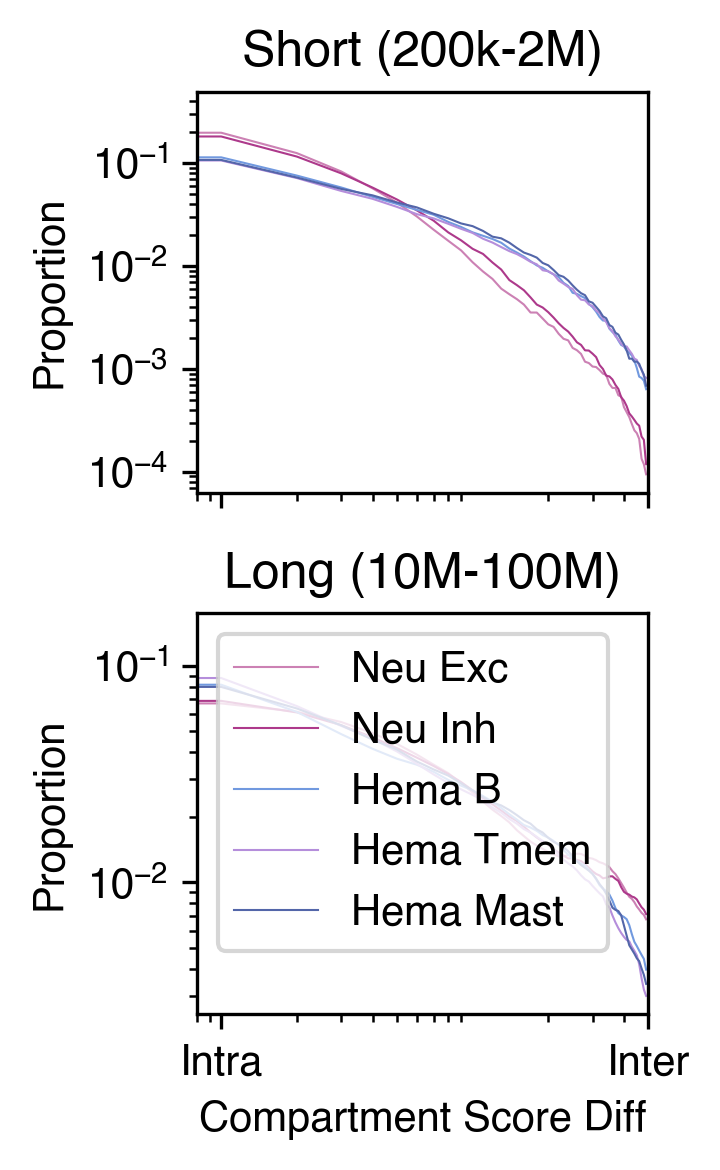

In [ ]:
l = np.around((np.log10([2e5,1e7]) - 5) * 100 / 3, decimals=0).astype(int)
r = np.around((np.log10([2e6,1e8]) - 5) * 100 / 3, decimals=0).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(2.5, 4), sharex='col', dpi=300)

for k,ax in enumerate(axes):
    for i,ct in enumerate(leg):
        if i>1 and i<(len(leg)-3):
            continue
        tmp = histdiff[i].copy()
        tmp = tmp[l[k]:r[k]].sum(axis=0)
        tmp = tmp / tmp.sum()
        ax.plot(np.arange(len(tmp)), tmp, color=L1_color[ct], linewidth=0.5, label=L1_annot[ct])
    ax.set_xlim([0.8, 50])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(['Short (200k-2M)', 'Long (10M-100M)'][k])
    ax.set_xticks([1, 50])
    ax.set_xticklabels(['Intra', 'Inter'])
    ax.set_ylabel('Proportion')
    
ax.legend()
ax.set_xlabel('Compartment Score Diff')
fig.tight_layout()
fig.savefig('decay_compartment/compdiff_shortlong_lineplot.pdf', transparent=True)


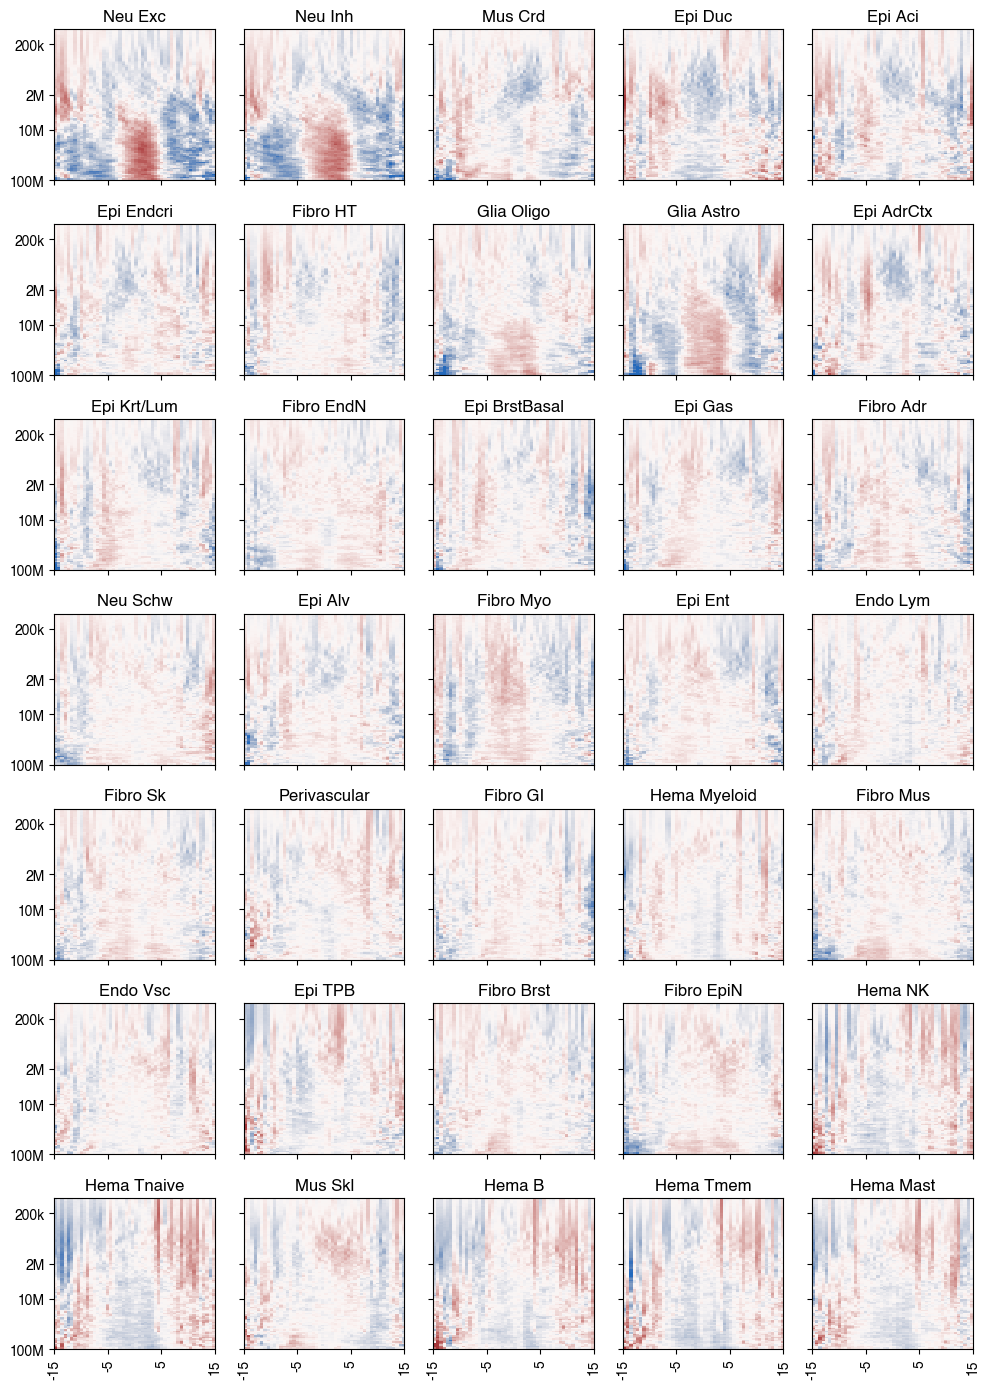

In [ ]:
fig, axes = plt.subplots(7, 5, figsize=(10, 14), sharex='all', sharey='all')
for i,ct in enumerate(leg):
    ax = axes.flatten()[i]
    tmp = histsum[i].copy()
    tmp = tmp / tmp.sum(axis=1)[:, None]
    tmp = np.log2(tmp / refsum)
    xticks = sumticks.copy()
    xticklabels = sumticklabels.copy()
    ax.imshow(tmp, cmap='vlag', aspect='auto', interpolation='none', vmin=-1, vmax=1)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=90)
    ax.set_title(L1meta.loc[ct, 'L1_abbr'])
    ax.set_yticks(distticks)
    ax.set_yticklabels(distticklabels)

plt.tight_layout()
fig.savefig('decay_compartment/compsum_dist_heatmap.pdf', transparent=True)


In [ ]:
n_convolve = 3
weights = np.ones(n_convolve) / n_convolve
from scipy.signal import convolve


In [ ]:
tmp = convolve(tmp, weights)[1:-1]

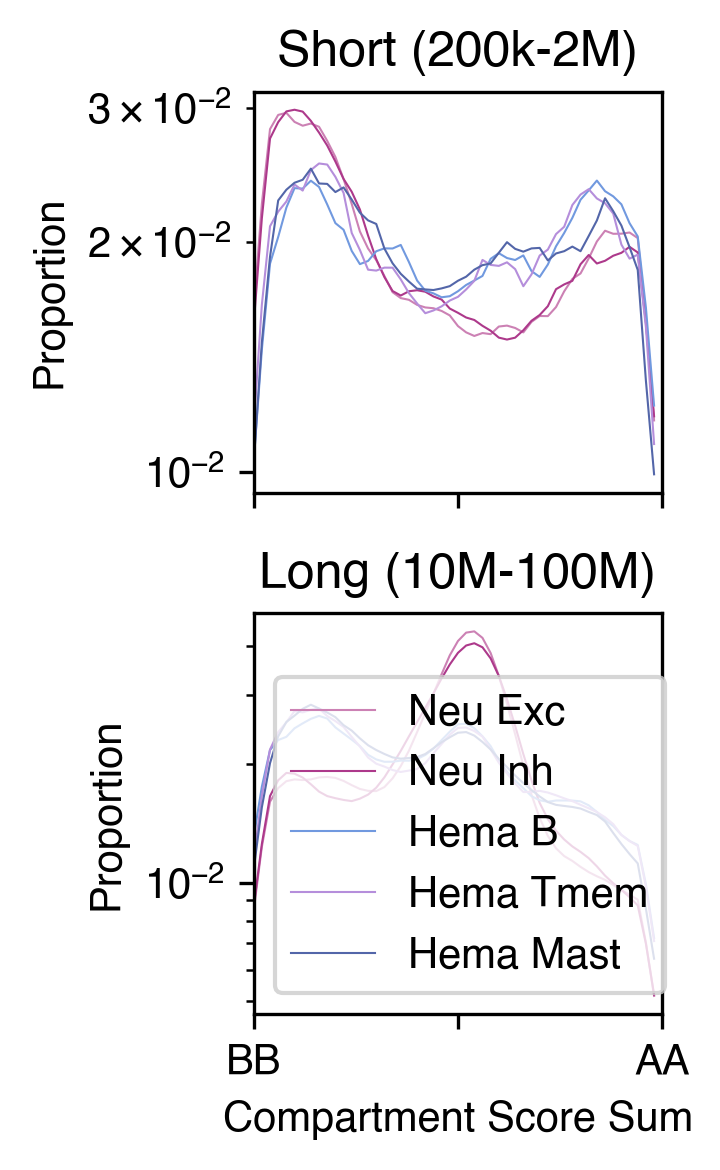

In [ ]:
l = np.around((np.log10([2e5,1e7]) - 5) * 100 / 3, decimals=0).astype(int)
r = np.around((np.log10([2e6,1e8]) - 5) * 100 / 3, decimals=0).astype(int)

pad = 2
n_convolve = 2*pad+1
weights = np.ones(n_convolve) / n_convolve

fig, axes = plt.subplots(2, 1, figsize=(2.5, 4), sharex='col', dpi=300)

for k,ax in enumerate(axes):
    for i,ct in enumerate(leg):
        if i>1 and i<(len(leg)-3):
            continue
        tmp = histsum[i].copy()
        tmp = tmp[l[k]:r[k]].sum(axis=0)
        tmp = tmp / tmp.sum()
        tmp = convolve(tmp, weights)[pad:-pad]
        ax.plot(np.arange(len(tmp)), tmp, color=L1_color[ct], linewidth=0.5, label=L1_annot[ct])
    ax.set_xlim([0.8, 50])
    # ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(['Short (200k-2M)', 'Long (10M-100M)'][k])
    ax.set_xticks([0, 25, 50])
    ax.set_xticklabels(['BB', '', 'AA'])
    ax.set_ylabel('Proportion')
    
ax.legend()
ax.set_xlabel('Compartment Score Sum')
fig.tight_layout()
fig.savefig('decay_compartment/compsum_shortlong_lineplot.pdf', transparent=True)
